In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muhammadhussnain09/water-quality-classification-for-rural-areas/Water Quality Classification for Rural Areas.csv


In [2]:
data=pd.read_csv('/kaggle/input/datasets/muhammadhussnain09/water-quality-classification-for-rural-areas/Water Quality Classification for Rural Areas.csv')

In [4]:
data.head()

,pH,Turbidity_NTU,Temperature_C,TDS_ppm,Conductivity_uS_cm,Dissolved_Oxygen_mg_L,Water_Quality
0,7.42,0.25,16.88,306.7,1486.1,7.41,Good
1,8.18,0.87,20.55,84.3,476.3,6.04,Moderate
2,5.58,1.99,26.25,676.7,479.9,6.71,Poor
3,7.93,0.06,30.15,852.9,713.5,3.24,Poor
4,8.37,3.37,12.32,161.2,1702.6,6.83,Poor


In [6]:
data=data[['Turbidity_NTU','Temperature_C','Water_Quality']]

In [7]:
data.shape

(450, 3)

In [9]:
data.isnull().sum()

Turbidity_NTU    0
Temperature_C    0
Water_Quality    0
dtype: int64

In [10]:
data.duplicated().sum()

np.int64(0)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Turbidity_NTU  450 non-null    float64
 1   Temperature_C  450 non-null    float64
 2   Water_Quality  450 non-null    object 
dtypes: float64(2), object(1)
memory usage: 10.7+ KB


In [15]:
data.head()

,Turbidity_NTU,Temperature_C,Water_Quality
0,0.25,16.88,Good
1,0.87,20.55,Moderate
2,1.99,26.25,Poor
3,0.06,30.15,Poor
4,3.37,12.32,Poor


Plotting: Turbidity_NTU


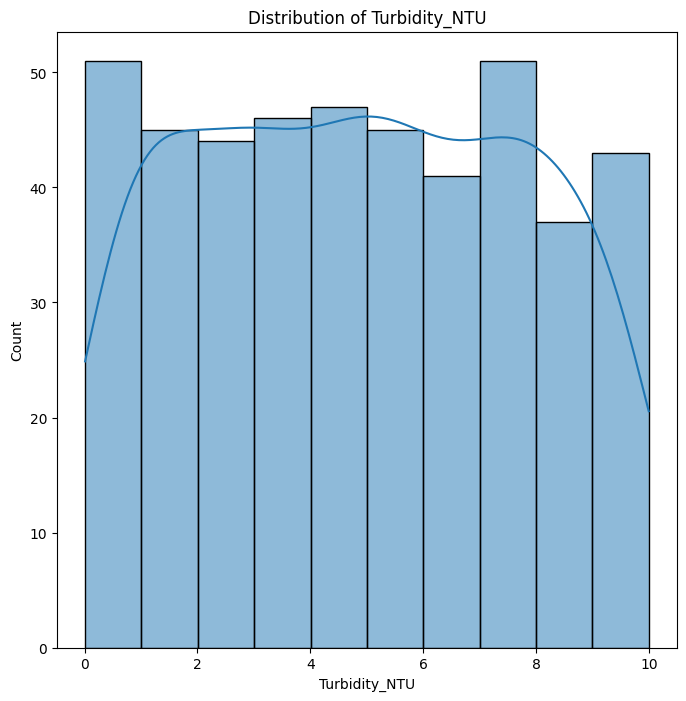

Plotting: Temperature_C


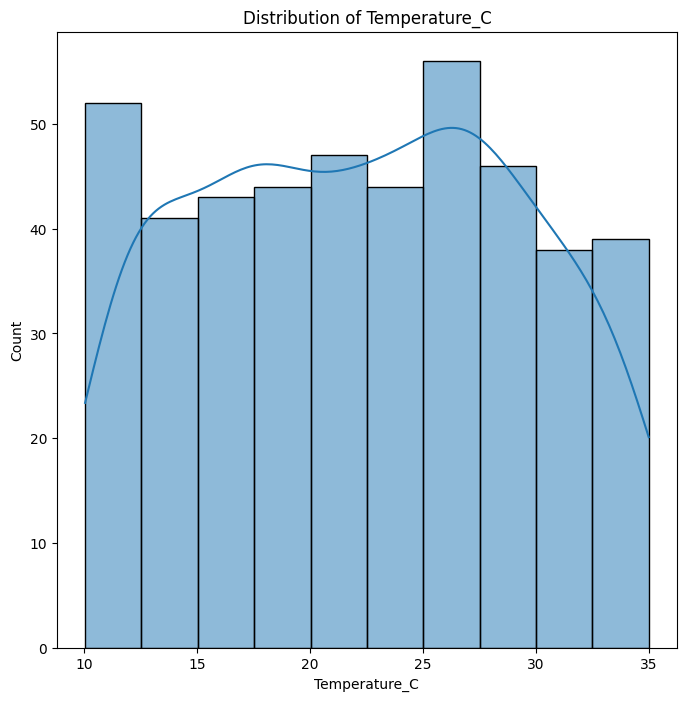

Plotting: Water_Quality


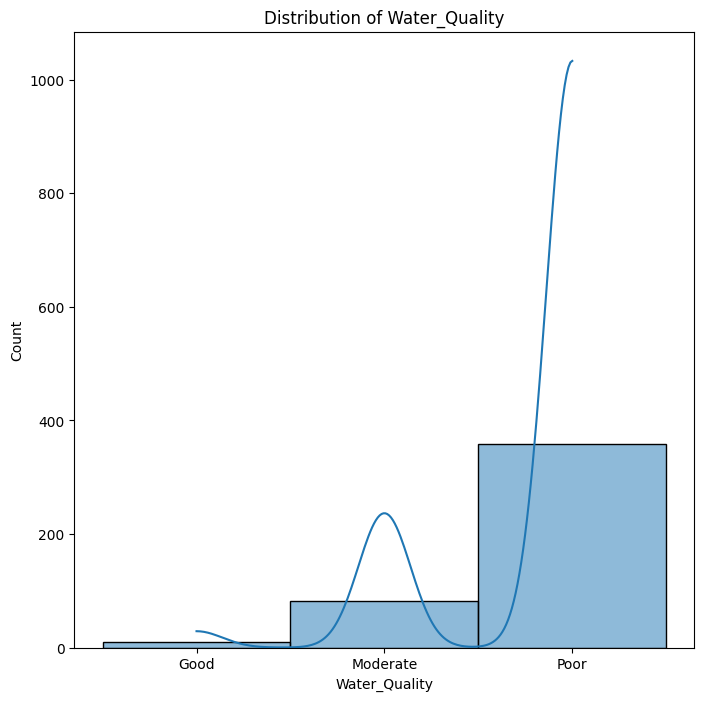

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

for i in data.columns:
    print(f"Plotting: {i}")
    plt.figure(figsize=(8, 8))          # ✅ plt.figure() use karo
    sns.histplot(data[i], kde=True)
    plt.title(f'Distribution of {i}')
    plt.show()                          # ✅ Show the plot

In [28]:
# Check current distribution
print(data['Water_Quality'].value_counts())

# Option A: Undersampling (Poor kam karo)
from sklearn.utils import resample

poor = data[data['Water_Quality'] == 'Poor']
moderate = data[data['Water_Quality'] == 'Moderate']
good = data[data['Water_Quality'] == 'Good']

# Downsample Poor to match Moderate (80 samples each)
poor_downsampled = resample(poor, replace=False, n_samples=80, random_state=42)

balanced_data = pd.concat([poor_downsampled, moderate, good])
print(balanced_data['Water_Quality'].value_counts())

Water_Quality
Poor        358
Moderate     82
Good         10
Name: count, dtype: int64
Water_Quality
Moderate    82
Poor        80
Good        10
Name: count, dtype: int64


In [29]:
balanced_data

,Turbidity_NTU,Temperature_C,Water_Quality
285,7.09,17.49,Poor
57,1.93,18.21,Poor
332,8.16,28.29,Poor
385,6.92,23.59,Poor
73,8.01,26.69,Poor
...,...,...,...
134,1.49,23.46,Good
236,0.86,34.37,Good
291,0.62,13.45,Good
338,1.34,16.07,Good


In [32]:
data.to_csv('water_quality.csv',index=False)

In [33]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# --- 1. Load Original Imbalanced Data ---
# (Main is assumption par chal raha hoon ki tumne uploaded "water_quality.csv" use ki hai)
# Agar nahi, toh apni file path daalo.
file_path = "water_quality.csv"
try:
    data_orig = pd.read_csv(file_path)
    # Hume sirf Sensors wale column aur Label chahiye
    cols_to_keep = ['TDS_ppm', 'Turbidity_NTU', 'Water_Quality']
    # Check if necessary columns exist
    if not all(col in data_orig.columns for col in cols_to_keep):
        # Trying to guess column names based on user input
        data_orig.columns = ['TDS_ppm', 'Turbidity_NTU', 'Water_Quality']
    data_orig = data_orig[cols_to_keep]
    print(f"Original Data Loaded. Shape: {data_orig.shape}")
except FileNotFoundError:
    # Creating a sample original DataFrame if the file isn't present
    print("Original file not found. Creating a sample original dataset.")
    data_dict = {
        'TDS_ppm': np.random.uniform(350, 500, 360), # Mainly Poor
        'Turbidity_NTU': np.random.uniform(5, 10, 360),
        'Water_Quality': ['Poor'] * 360
    }
    data_orig = pd.DataFrame(data_dict)

# Calculate current imbalance
counts = data_orig['Water_Quality'].value_counts()
print("\nCurrent Distribution:\n", counts)

# Targets based on User Request
target_good_samples = 400
target_moderate_samples = 400

# --- 2. Generate Synthetic 'Good' Water Data ---
# WHO Ideal Standard: TDS < 150ppm, Turbidity < 1 NTU
num_good_to_gen = target_good_samples - counts.get('Good', 0)
if num_good_to_gen > 0:
    good_data = pd.DataFrame({
        'TDS_ppm': np.random.uniform(50, 150, num_good_to_gen),
        'Turbidity_NTU': np.random.uniform(0.1, 1.0, num_good_to_gen),
        'Water_Quality': ['Good'] * num_good_to_gen
    })
else:
    good_data = pd.DataFrame(columns=cols_to_keep)

# --- 3. Generate Synthetic 'Moderate' Water Data ---
# WHO Acceptable Standard: TDS 150-300ppm, Turbidity 1-3 NTU
num_mod_to_gen = target_moderate_samples - counts.get('Moderate', 0)
if num_mod_to_gen > 0:
    mod_data = pd.DataFrame({
        'TDS_ppm': np.random.uniform(151, 300, num_mod_to_gen),
        'Turbidity_NTU': np.random.uniform(1.1, 3.0, num_mod_to_gen),
        'Water_Quality': ['Moderate'] * num_mod_to_gen
    })
else:
    mod_data = pd.DataFrame(columns=cols_to_keep)

# --- 4. Combine and Save ---
balanced_data = pd.concat([data_orig, good_data, mod_data], ignore_index=True)

# Shuffle the data so 'Poor' isn't all at the top
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Final Count Check
print("\nFinal Balanced Distribution:\n", balanced_data['Water_Quality'].value_counts())

# Save to new CSV
balanced_filename = "balanced_water_quality_sensors_only.csv"
balanced_data.to_csv(balanced_filename, index=False)
print(f"\n✅ Data generated and saved as: {balanced_filename}")

Original Data Loaded. Shape: (450, 3)

Current Distribution:
 Water_Quality
Poor        358
Moderate     82
Good         10
Name: count, dtype: int64

Final Balanced Distribution:
 Water_Quality
Moderate    400
Good        400
Poor        358
Name: count, dtype: int64

✅ Data generated and saved as: balanced_water_quality_sensors_only.csv


In [35]:
balanced_data.head()

,TDS_ppm,Turbidity_NTU,Water_Quality
0,251.112019,1.347164,Moderate
1,8.460000,16.270000,Poor
2,4.010000,11.850000,Poor
3,1.370000,25.390000,Moderate
4,104.063512,0.556849,Good


In [39]:
data=balanced_data

Plotting: TDS_ppm


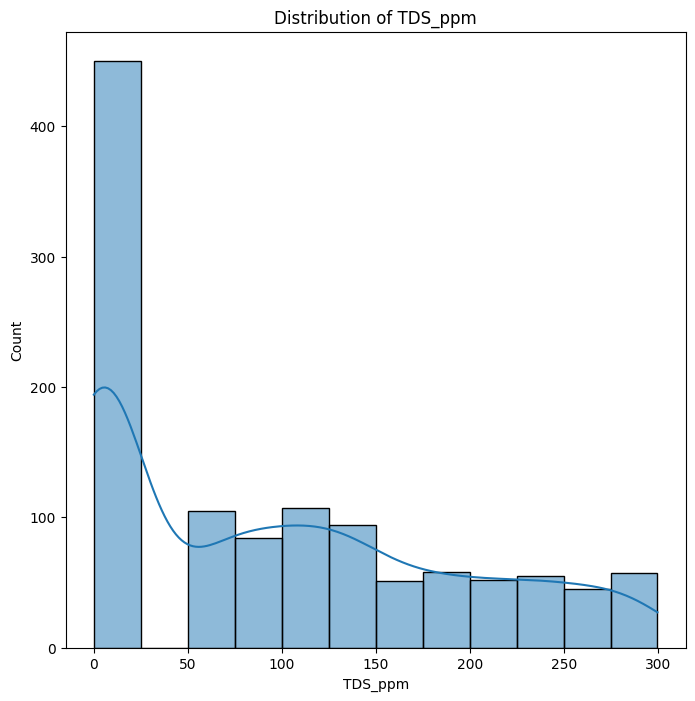

Plotting: Turbidity_NTU


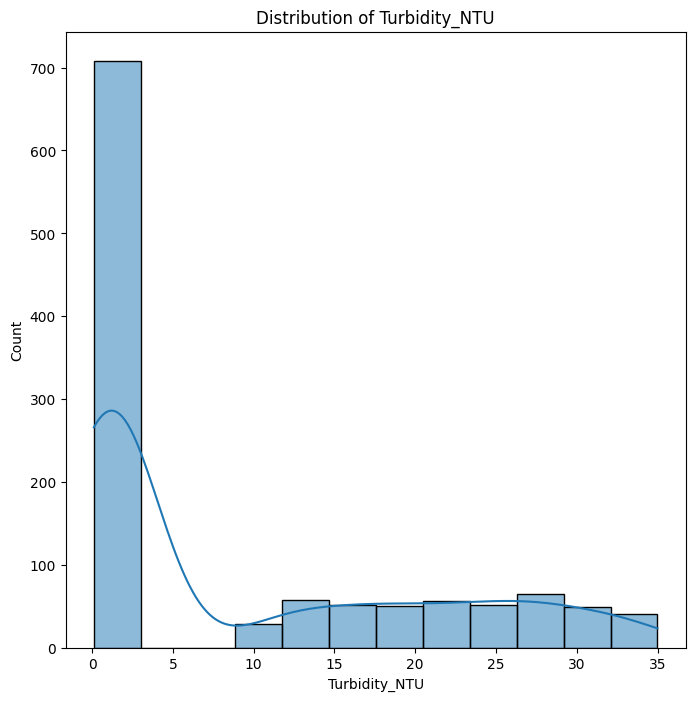

Plotting: Water_Quality


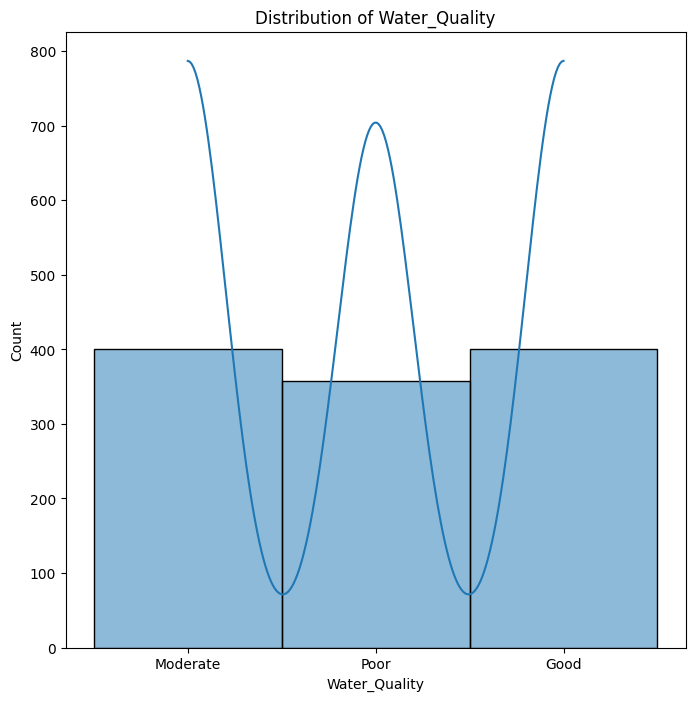

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

for i in data.columns:
    print(f"Plotting: {i}")
    plt.figure(figsize=(8, 8))          # ✅ plt.figure() use karo
    sns.histplot(data[i], kde=True)
    plt.title(f'Distribution of {i}')
    plt.show()                          # ✅ Show the plot

In [42]:
data.shape

(1158, 3)

In [45]:
from sklearn.model_selection import train_test_split

In [49]:
x=data.iloc[:,:-1]
y=data.iloc[:,-1]

0       Moderate
1           Poor
2           Poor
3       Moderate
4           Good
          ...   
1153    Moderate
1154    Moderate
1155    Moderate
1156    Moderate
1157    Moderate
Name: Water_Quality, Length: 1158, dtype: object

In [55]:
def text_to_number(text):
    if text =='Moderate':
        return 1
    elif text=='Poor':
        return 0
    else :
        return 2

In [61]:
y=data['Water_Quality'].apply(text_to_number)

In [65]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
# Model define karna best params ke saath
model = RandomForestClassifier(
    n_estimators=100, 
    criterion='gini', 
    max_depth=None, 
    min_samples_split=2, 
    random_state=42
)

# Training
model.fit(x_train, y_train)

# Prediction
predictions = model.predict(x_test)

In [72]:
from sklearn.metrics import accuracy_score

In [73]:
accuracy_score(y_test,predictions)

0.9137931034482759